In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from collections import Counter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            classification_report, confusion_matrix, roc_auc_score, 
                            precision_recall_curve, auc, roc_curve)
import time

# Configuración para visualización
plt.style.use('ggplot')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
import os
import matplotlib.pyplot as plt

# Configurar directorio para guardar plots
PLOTS_DIR = os.path.join('..', 'results', 'plots', 'analysis')
os.makedirs(PLOTS_DIR, exist_ok=True)

# Contador para numeración automática de plots
plot_counter = 1

def save_plot(filename=None, dpi=300, bbox_inches='tight'):
    """
    Guarda el plot actual en el directorio de plots.
    
    Args:
        filename (str): Nombre del archivo. Si es None, se genera automáticamente.
        dpi (int): Resolución de la imagen.
        bbox_inches (str): Configuración de recorte de la imagen.
    """
    global plot_counter
    
    if filename is None:
        filename = f"plot_{plot_counter:02d}.png"
        plot_counter += 1
    
    # Asegurar que termine en .png
    if not filename.endswith('.png'):
        filename += '.png'
    
    filepath = os.path.join(PLOTS_DIR, filename)
    plt.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches)
    print(f"Plot guardado: {filepath}")

# Función para mostrar y guardar plot simultáneamente
def show_and_save(filename=None):
    """
    Muestra el plot y lo guarda automáticamente.
    """
    save_plot(filename)
    plt.show()

In [5]:
# 1. CARGA DE DATOS
# Cargar el archivo CSV en un DataFrame
df = pd.read_csv(os.path.join('..', 'data', 'raw', 'creditcard.csv'))

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

Dimensiones del dataset: 284807 filas x 31 columnas


In [7]:
# 2. ANÁLISIS EXPLORATORIO INICIAL
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
# Información general del dataset
print("\nInformación general del dataset:")
df.info()


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807

In [11]:
# Ver distribución de valores nulos
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [13]:
# Distribución de la variable objetivo 
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print(f"\nTotal de transacciones: {len(df)}")
print(f"Transacciones normales: {len(normal)}")
print(f"Transacciones fraudulentas: {len(fraud)}")
print(f"Porcentaje de fraudes: {len(fraud)/len(df)*100:.4f}%")
print(f"Ratio de desbalance: 1:{len(normal)/len(fraud):.2f}")


Total de transacciones: 284807
Transacciones normales: 284315
Transacciones fraudulentas: 492
Porcentaje de fraudes: 0.1727%
Ratio de desbalance: 1:577.88


Plot guardado: ..\results\plots\analysis\01_distribucion_clases.png


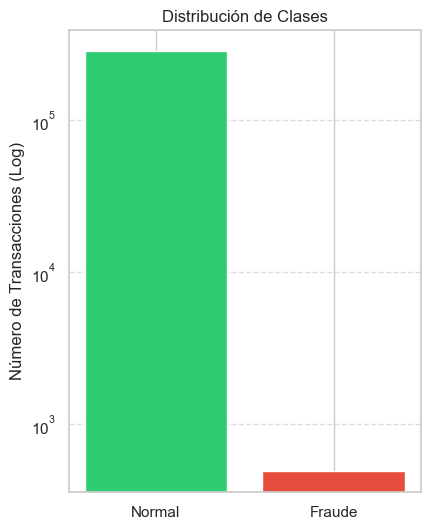

In [17]:
# Visualización mejorada del desbalance
plt.figure(figsize=(10, 6))
labels = ['Normal', 'Fraude']
counts = [len(normal), len(fraud)]

# Gráfico de barras con escala logarítmica
plt.subplot(1, 2, 1)
ax = plt.bar(labels, counts, color=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Clases')
plt.ylabel('Número de Transacciones (Log)')
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
show_and_save("01_distribucion_clases")

In [19]:
# 3. ANÁLISIS DE CARACTERÍSTICAS PRINCIPALES
# Comparación de Amount entre transacciones normales y fraudulentas
print("\nEstadísticas de Amount para transacciones normales:")
print(normal['Amount'].describe())
print("\nEstadísticas de Amount para transacciones fraudulentas:")
print(fraud['Amount'].describe())


Estadísticas de Amount para transacciones normales:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Estadísticas de Amount para transacciones fraudulentas:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


Plot guardado: ..\results\plots\analysis\02_boxplots_amount.png


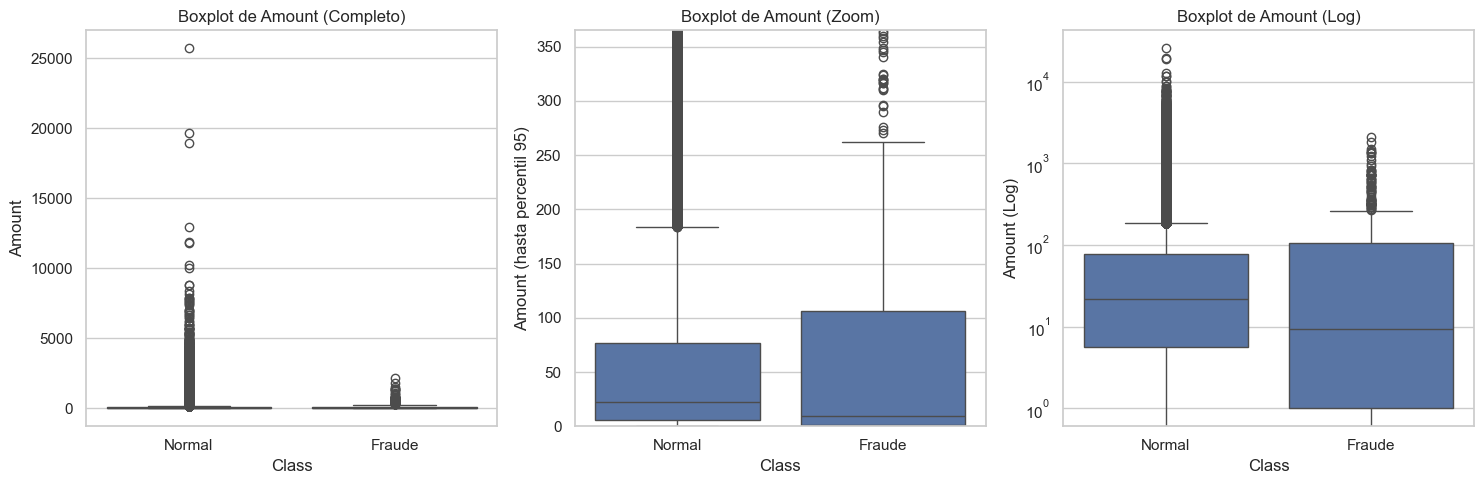

In [21]:
plt.figure(figsize=(15, 5))

# Boxplot completo
plt.subplot(1, 3, 1)
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Boxplot de Amount (Completo)')
plt.xticks([0, 1], ['Normal', 'Fraude'])
plt.ylabel('Amount')

# Boxplot con zoom en el rango principal
plt.subplot(1, 3, 2)
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Boxplot de Amount (Zoom)')
plt.xticks([0, 1], ['Normal', 'Fraude'])
plt.ylim(0, df['Amount'].quantile(0.95))  # Zoom hasta el percentil 95
plt.ylabel('Amount (hasta percentil 95)')

# Boxplot con escala logarítmica
plt.subplot(1, 3, 3)
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Boxplot de Amount (Log)')
plt.xticks([0, 1], ['Normal', 'Fraude'])
plt.yscale('log')
plt.ylabel('Amount (Log)')

plt.tight_layout()
show_and_save("02_boxplots_amount")

In [23]:
# 4. ANÁLISIS TEMPORAL
# Convertir la variable Time a horas
df['Time_Hour'] = df['Time'] / 3600

# Extraer la hora del día en dos formatos:

# 1. Hora del día como decimal (0-23.999...)
df['Hour_of_Day'] = df['Time_Hour'] % 24

# 2. Hora del día como entero (0-23)
df['Hour_of_Day_Int'] = df['Hour_of_Day'].astype(int)

print(f"Rango de Time_Hour: {df['Time_Hour'].min():.2f} a {df['Time_Hour'].max():.2f} horas")
print(f"Rango de Hour_of_Day: {df['Hour_of_Day'].min():.2f} a {df['Hour_of_Day'].max():.2f} horas")
print(f"Valores únicos de Hour_of_Day_Int: {sorted(df['Hour_of_Day_Int'].unique())}")

Rango de Time_Hour: 0.00 a 48.00 horas
Rango de Hour_of_Day: 0.00 a 24.00 horas
Valores únicos de Hour_of_Day_Int: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


Plot guardado: ..\results\plots\analysis\03_distribucion_temporal_intervalos.png


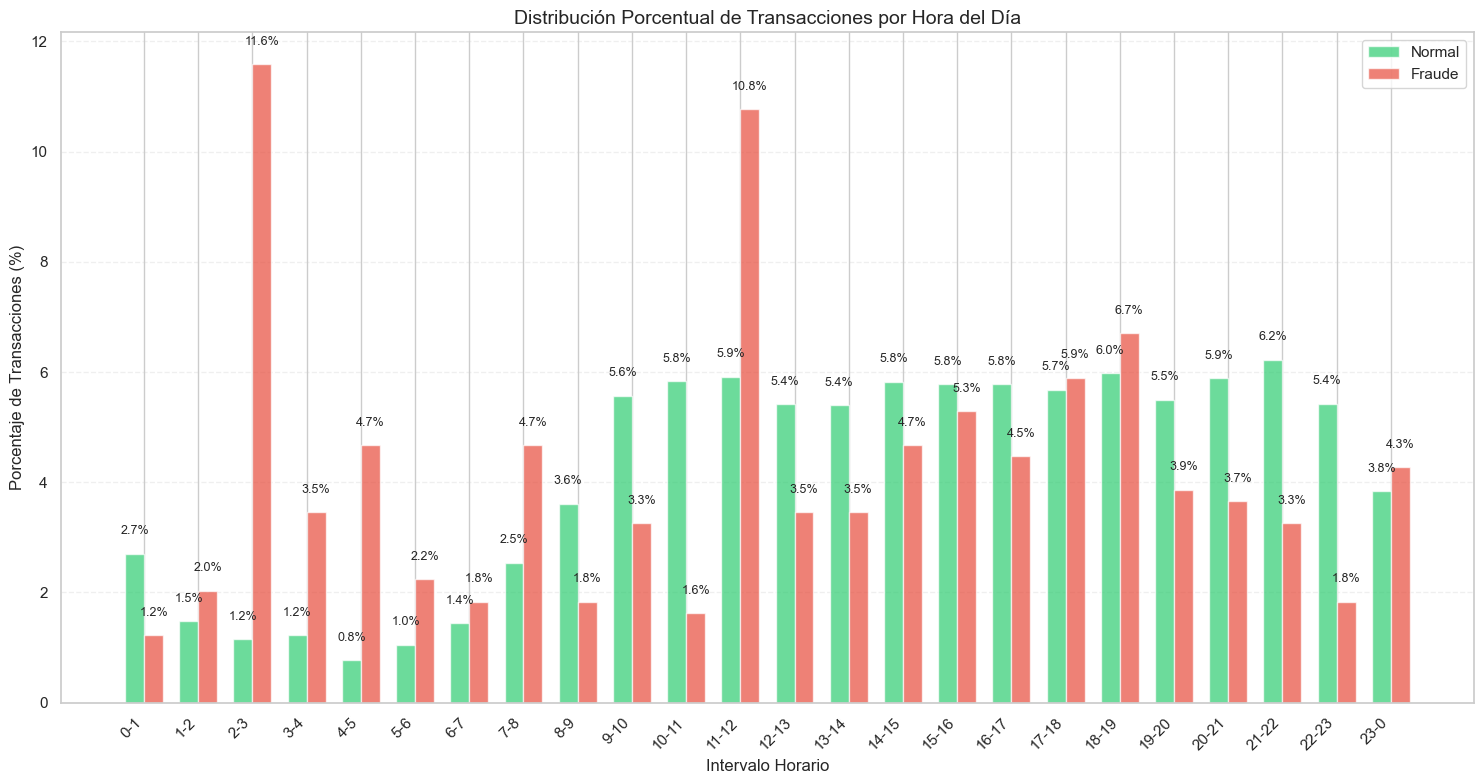

In [25]:
# Análisis de distribución horaria con formato entero

# Calcular distribución por hora del día para cada clase
fraud_hourly = df[df['Class'] == 1].groupby('Hour_of_Day_Int').size()
normal_hourly = df[df['Class'] == 0].groupby('Hour_of_Day_Int').size()

# Asegurar que tenemos todas las horas del día (0-23)
all_hours = pd.Series(index=range(24), data=0)
fraud_hourly = fraud_hourly.add(all_hours, fill_value=0)
normal_hourly = normal_hourly.add(all_hours, fill_value=0)

# Ordenar por hora
fraud_hourly = fraud_hourly.sort_index()
normal_hourly = normal_hourly.sort_index()

# Convertir a porcentajes
fraud_hourly_pct = (fraud_hourly / fraud_hourly.sum()) * 100
normal_hourly_pct = (normal_hourly / normal_hourly.sum()) * 100

# Visualización con barras agrupadas para intervalos de una hora
plt.figure(figsize=(15, 8))

# Definir posiciones de barras y etiquetas
x = np.arange(24)  
width = 0.35 

# Crear etiquetas para intervalos de una hora
hour_labels = [f"{h}-{h+1}" if h < 23 else "23-0" for h in range(24)]

# Crear barras
ax = plt.subplot(111)
normal_bars = ax.bar(x - width/2, normal_hourly_pct, width, color='#2ecc71', label='Normal', alpha=0.7)
fraud_bars = ax.bar(x + width/2, fraud_hourly_pct, width, color='#e74c3c', label='Fraude', alpha=0.7)

# Añadir etiquetas y título
ax.set_xlabel('Intervalo Horario', fontsize=12)
ax.set_ylabel('Porcentaje de Transacciones (%)', fontsize=12)
ax.set_title('Distribución Porcentual de Transacciones por Hora del Día', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(hour_labels, rotation=45, ha='right')
ax.legend()

# Añadir grid para mejor visualización
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Añadir etiquetas de porcentaje sobre barras con valores significativos
threshold = 0.0
for i, bar in enumerate(normal_bars):
    if normal_hourly_pct[i] > threshold:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{normal_hourly_pct[i]:.1f}%', ha='center', va='bottom', fontsize=9)
        
for i, bar in enumerate(fraud_bars):
    if fraud_hourly_pct[i] > threshold:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                f'{fraud_hourly_pct[i]:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
show_and_save("03_distribucion_temporal_intervalos")

Plot guardado: ..\results\plots\analysis\04_distribucion_temporal_separada.png


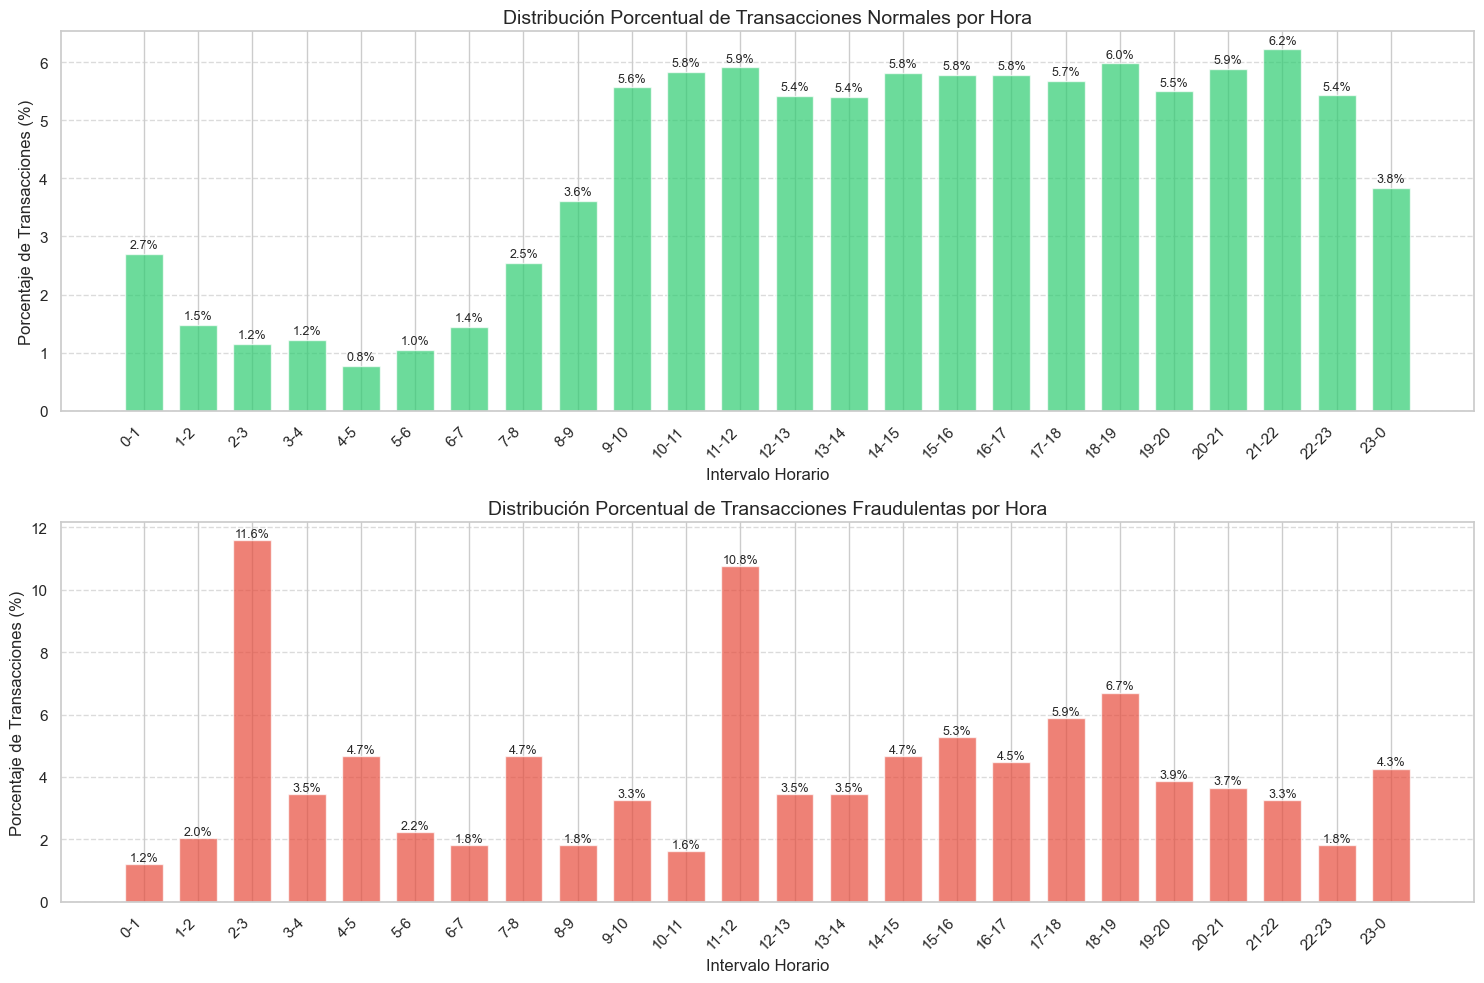

In [27]:
# Visualización alternativa: dos gráficos separados para ver mejor los detalles
plt.figure(figsize=(15, 10))

# Gráfico para transacciones normales
plt.subplot(2, 1, 1)
bars = plt.bar(x, normal_hourly_pct, width=0.7, color='#2ecc71', alpha=0.7)
plt.title('Distribución Porcentual de Transacciones Normales por Hora', fontsize=14)
plt.xlabel('Intervalo Horario')
plt.ylabel('Porcentaje de Transacciones (%)')
plt.xticks(x, hour_labels, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir valores sobre las barras
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1, 
            f'{normal_hourly_pct[i]:.1f}%', ha='center', fontsize=9)

# Gráfico para transacciones fraudulentas
plt.subplot(2, 1, 2)
bars = plt.bar(x, fraud_hourly_pct, width=0.7, color='#e74c3c', alpha=0.7)
plt.title('Distribución Porcentual de Transacciones Fraudulentas por Hora', fontsize=14)
plt.xlabel('Intervalo Horario')
plt.ylabel('Porcentaje de Transacciones (%)')
plt.xticks(x, hour_labels, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir valores sobre las barras
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1, 
            f'{fraud_hourly_pct[i]:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
show_and_save("04_distribucion_temporal_separada")

In [29]:
# 5. ANÁLISIS DE CORRELACIÓN Y VARIABLES IMPORTANTES
# Correlación con la variable objetivo
corr_with_target = df.corr()['Class']

# Ordenamos por valor absoluto para identificar las variables más influyentes
abs_corr_with_target = corr_with_target.abs().sort_values(ascending=False)
corr_with_target_sorted = corr_with_target[abs_corr_with_target.index]

print("\nCorrelación de las variables con la clase objetivo (ordenadas por valor absoluto):")
print(corr_with_target_sorted)


Correlación de las variables con la clase objetivo (ordenadas por valor absoluto):
Class              1.000000
V17               -0.326481
V14               -0.302544
V12               -0.260593
V10               -0.216883
V16               -0.196539
V3                -0.192961
V7                -0.187257
V11                0.154876
V4                 0.133447
V18               -0.111485
V1                -0.101347
V9                -0.097733
V5                -0.094974
V2                 0.091289
V6                -0.043643
V21                0.040413
V19                0.034783
V20                0.020090
V8                 0.019875
V27                0.017580
Hour_of_Day_Int   -0.017109
Hour_of_Day       -0.017082
Time_Hour         -0.012323
Time              -0.012323
V28                0.009536
V24               -0.007221
Amount             0.005632
V13               -0.004570
V26                0.004455
V15               -0.004223
V25                0.003308
V23               -0

Plot guardado: ..\results\plots\analysis\05_correlaciones_top10.png


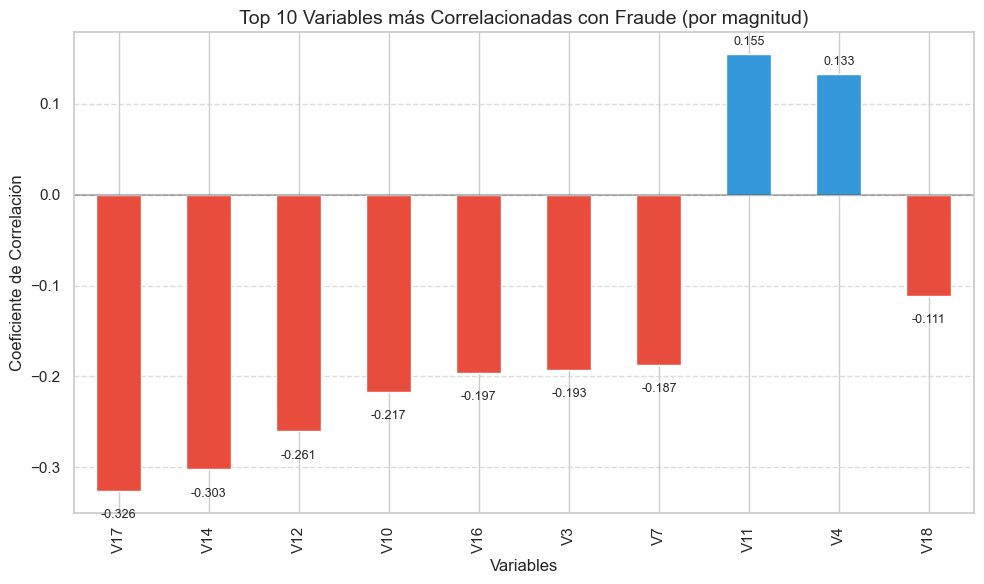

In [31]:
# Visualización de correlaciones con la clase objetivo
plt.figure(figsize=(10, 6))
top_corr = corr_with_target_sorted[1:11]  # Excluye la propia clase

# Colores basados en el signo de la correlación
colors = ['#3498db' if c > 0 else '#e74c3c' for c in top_corr]

# Gráfico de barras ordenado por magnitud pero manteniendo el signo original
ax = top_corr.plot(kind='bar', color=colors, figsize=(10, 6))
plt.title('Top 10 Variables más Correlacionadas con Fraude (por magnitud)', fontsize=14)
plt.xlabel('Variables')
plt.ylabel('Coeficiente de Correlación')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas con valores exactos
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.01 if height >= 0 else height - 0.03, 
            f'{height:.3f}', ha="center", fontsize=9)

plt.tight_layout()
show_and_save("05_correlaciones_top10")

Plot guardado: ..\results\plots\analysis\06_distribuciones_variables_importantes.png


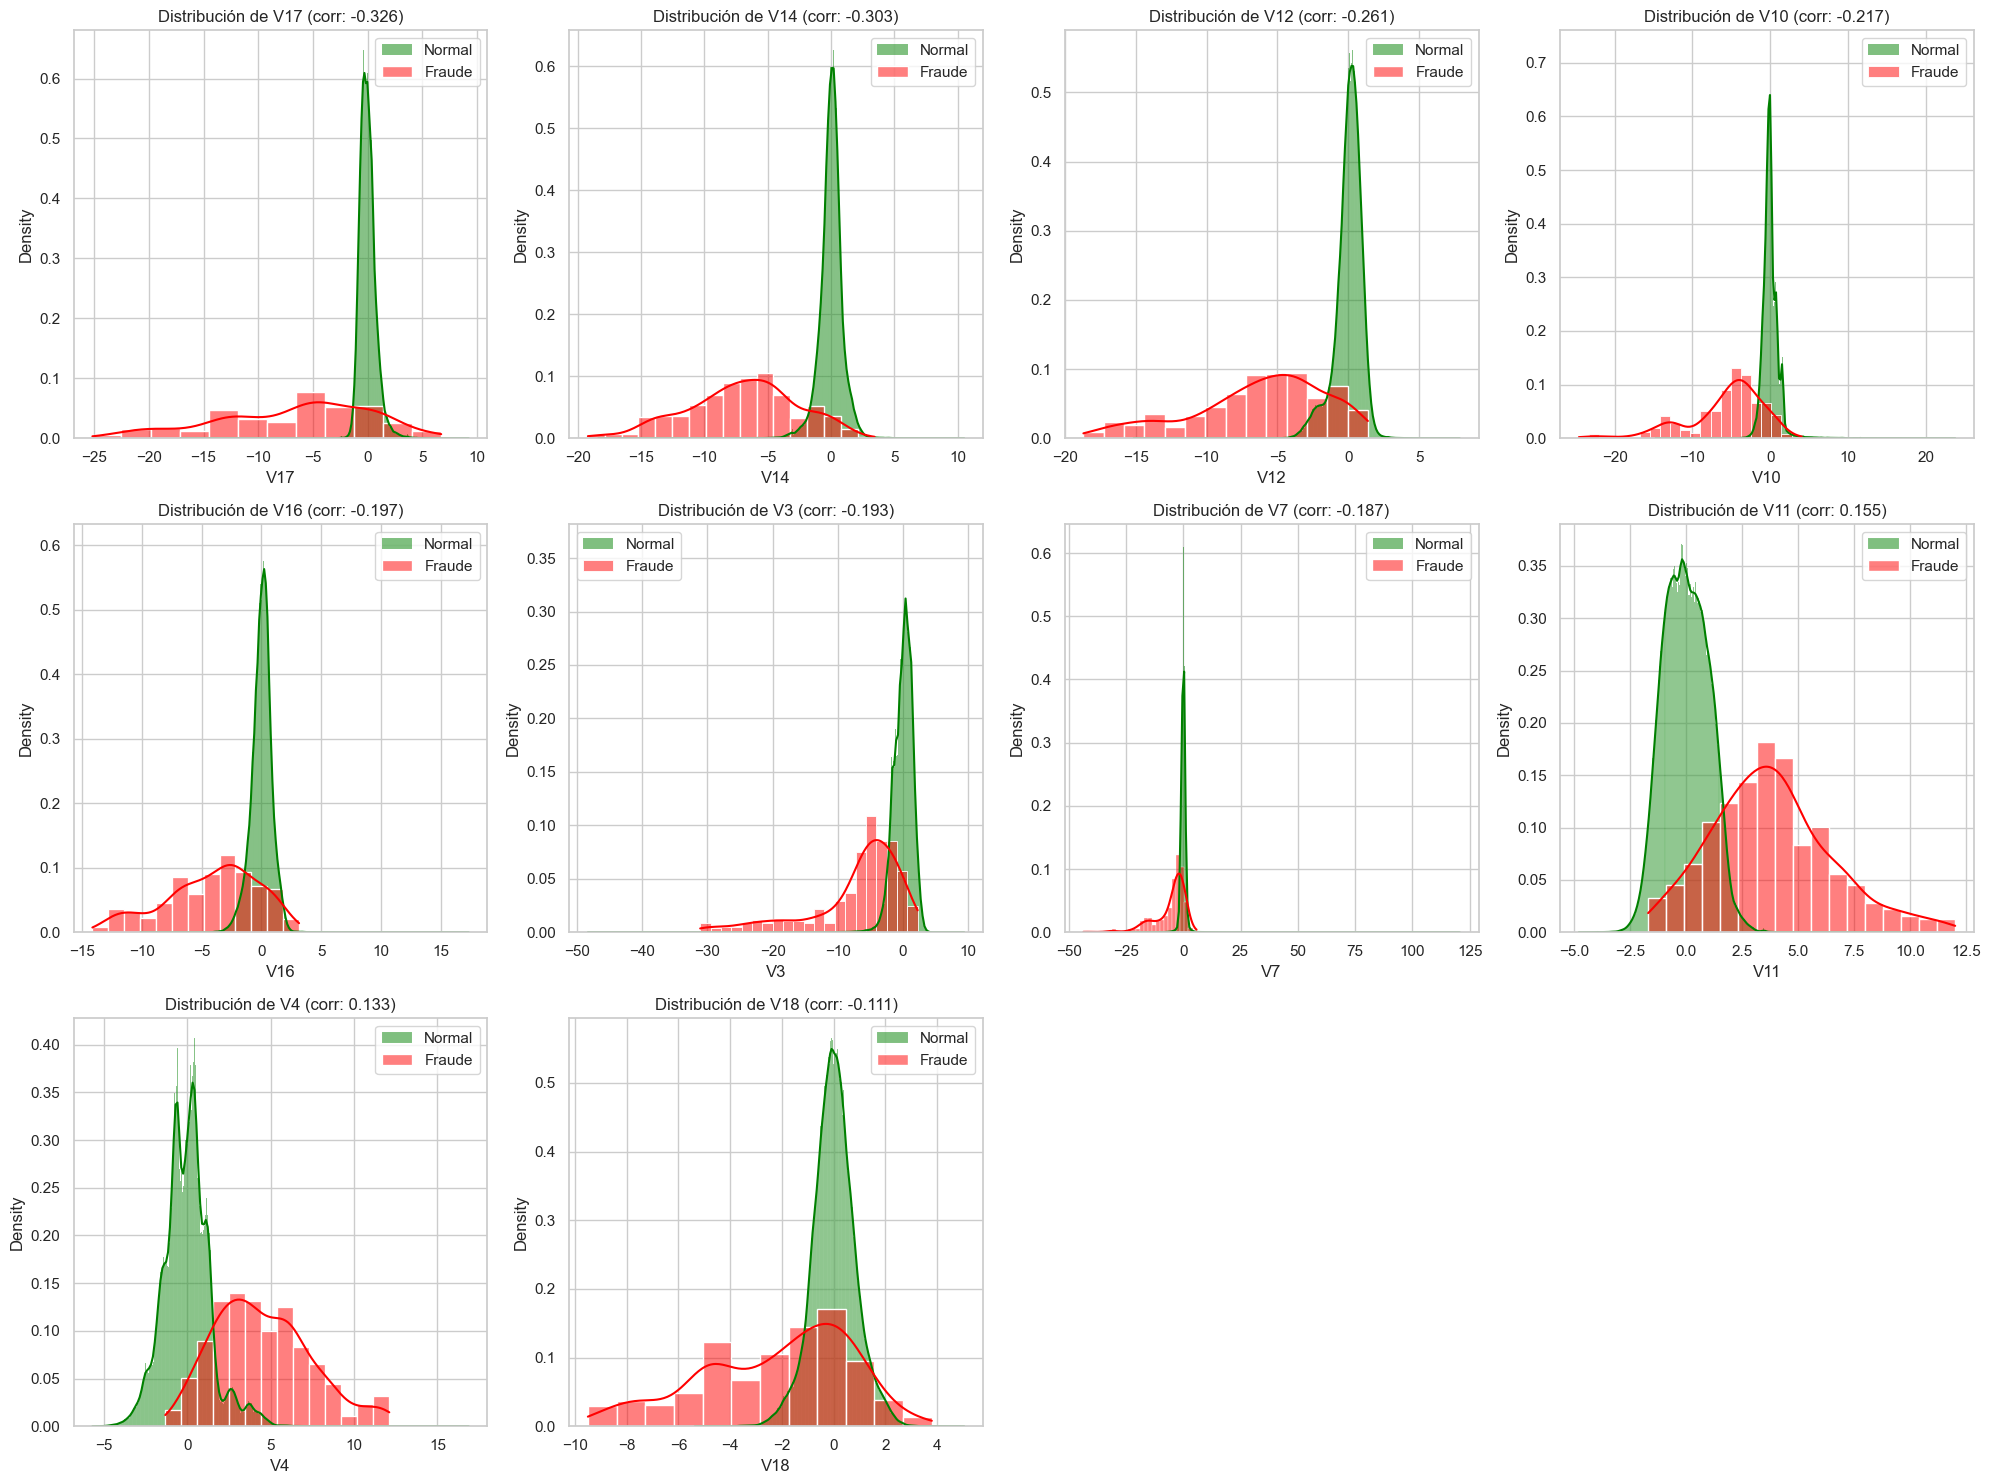

In [33]:
# Visualización de variables importantes
plt.figure(figsize=(20, 15))
for i, feature in enumerate(top_corr.index[:10]):
    plt.subplot(3, 4, i+1)
    
    # Histogramas superpuestos
    sns.histplot(normal[feature], color='green', label='Normal', kde=True, stat='density', alpha=0.5)
    sns.histplot(fraud[feature], color='red', label='Fraude', kde=True, stat='density', alpha=0.5)
    
    corr_value = corr_with_target[feature]
    plt.title(f'Distribución de {feature} (corr: {corr_value:.3f})')
    plt.xlabel(feature)
    plt.legend()
plt.tight_layout()
show_and_save("06_distribuciones_variables_importantes")

In [35]:
# 6. DETECCIÓN DE OUTLIERS
# Análisis específico de outliers usando el método IQR
def identify_outliers_iqr(data, feature):
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Aplicamos el método a Amount para cada clase
normal_outliers, normal_lb, normal_ub = identify_outliers_iqr(normal, 'Amount')
fraud_outliers, fraud_lb, fraud_ub = identify_outliers_iqr(fraud, 'Amount')

print(f"\nOutliers en transacciones normales (Amount):")
print(f"  - Límite inferior: {normal_lb:.2f}")
print(f"  - Límite superior: {normal_ub:.2f}")
print(f"  - Número de outliers: {len(normal_outliers)} ({len(normal_outliers)/len(normal)*100:.2f}%)")

print(f"\nOutliers en transacciones fraudulentas (Amount):")
print(f"  - Límite inferior: {fraud_lb:.2f}")
print(f"  - Límite superior: {fraud_ub:.2f}")
print(f"  - Número de outliers: {len(fraud_outliers)} ({len(fraud_outliers)/len(fraud)*100:.2f}%)")


Outliers en transacciones normales (Amount):
  - Límite inferior: -101.45
  - Límite superior: 184.15
  - Número de outliers: 31862 (11.21%)

Outliers en transacciones fraudulentas (Amount):
  - Límite inferior: -156.34
  - Límite superior: 263.23
  - Número de outliers: 69 (14.02%)
